# Microsoft Planetary Computer Met Office check

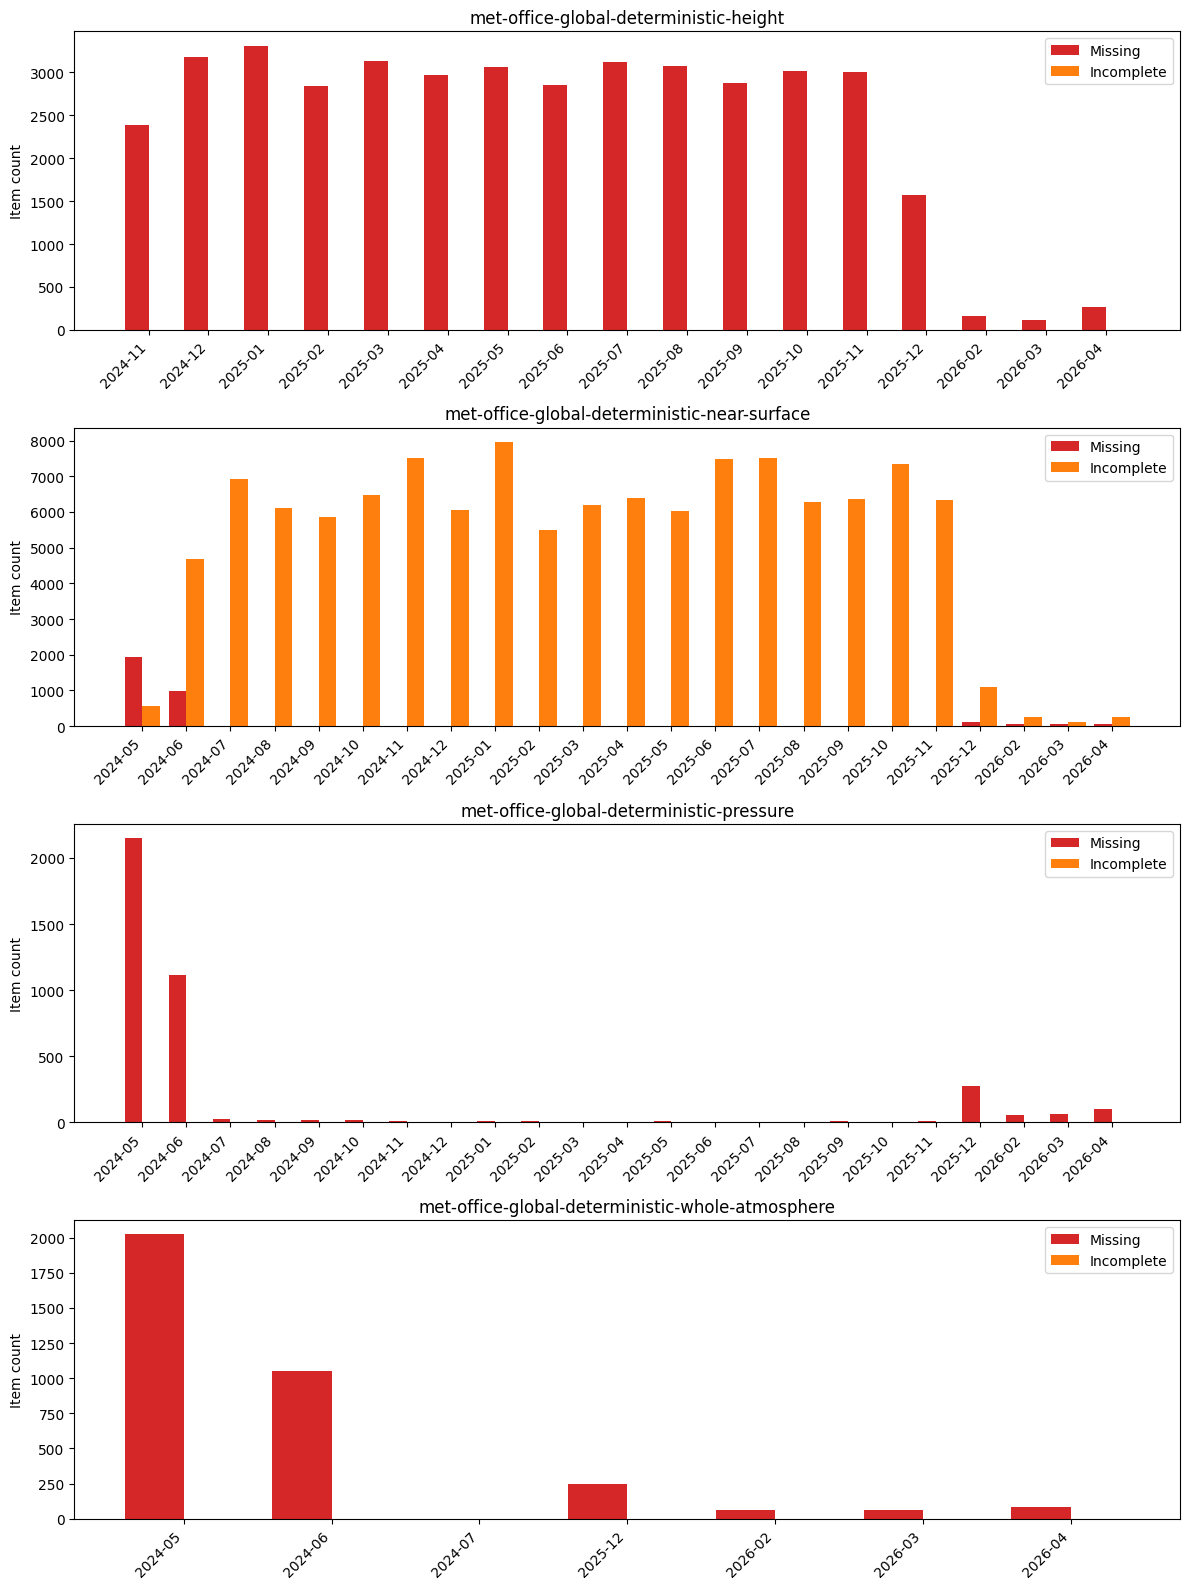

In [2]:
from collections import defaultdict

from geopandas import GeoDataFrame
import matplotlib.pyplot as plt
import pandas
from rustac import DuckdbClient

client = DuckdbClient()
data_frame = pandas.read_parquet("check-global.parquet")

collections = [
    "met-office-global-deterministic-height",
    "met-office-global-deterministic-near-surface",
    "met-office-global-deterministic-pressure",
    "met-office-global-deterministic-whole-atmosphere",
]

fig, axes = plt.subplots(len(collections), 1, figsize=(12, 4 * len(collections)))

for ax, collection in zip(axes, collections):
    table = client.search_to_arrow(f"data/{collection}.parquet")
    stac_data_frame = GeoDataFrame.from_arrow(table)

    collection_data_frame = data_frame[data_frame["collection"] == collection]
    stac_assets_by_id = dict(zip(stac_data_frame["id"], stac_data_frame["assets"]))

    missing_by_month: dict[str, int] = defaultdict(int)
    incomplete_by_month: dict[str, int] = defaultdict(int)

    for item_id, item_data_frame in collection_data_frame.groupby("item"):
        month = f"{item_id[:4]}-{item_id[4:6]}"
        if item_id not in stac_assets_by_id:
            missing_by_month[month] += 1
            continue
        expected_variables = {
            path.split("/")[-1].removesuffix(".nc").split("-")[-1]
            for path in item_data_frame["path"]
        }
        actual_keys = set(stac_assets_by_id[item_id].keys())
        if expected_variables - actual_keys:
            incomplete_by_month[month] += 1

    months = sorted(set(missing_by_month) | set(incomplete_by_month))
    missing_counts = [missing_by_month[m] for m in months]
    incomplete_counts = [incomplete_by_month[m] for m in months]

    x = range(len(months))
    width = 0.4
    ax.bar([i - width / 2 for i in x], missing_counts, width, label="Missing", color="tab:red")
    ax.bar([i + width / 2 for i in x], incomplete_counts, width, label="Incomplete", color="tab:orange")
    ax.set_xticks(list(x))
    ax.set_xticklabels(months, rotation=45, ha="right")
    ax.set_title(collection)
    ax.set_ylabel("Item count")
    ax.legend()

plt.tight_layout()
plt.show()